In [87]:
from ISLP import load_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pygam import LinearGAM, s, f, terms
from sklearn.preprocessing import LabelEncoder
import pygam

In [3]:
wage = load_data("Wage")
wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [12]:
wage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        3000 non-null   int64   
 1   age         3000 non-null   int64   
 2   maritl      3000 non-null   category
 3   race        3000 non-null   category
 4   education   3000 non-null   category
 5   region      3000 non-null   category
 6   jobclass    3000 non-null   category
 7   health      3000 non-null   category
 8   health_ins  3000 non-null   category
 9   logwage     3000 non-null   float64 
 10  wage        3000 non-null   float64 
dtypes: category(7), float64(2), int64(2)
memory usage: 115.5 KB


<Axes: >

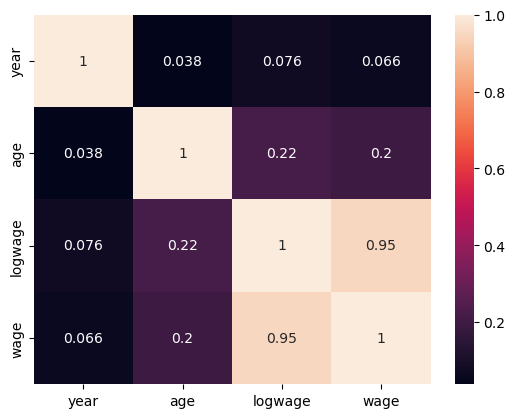

In [16]:
sns.heatmap(wage.select_dtypes(include='number').corr(), annot=True)

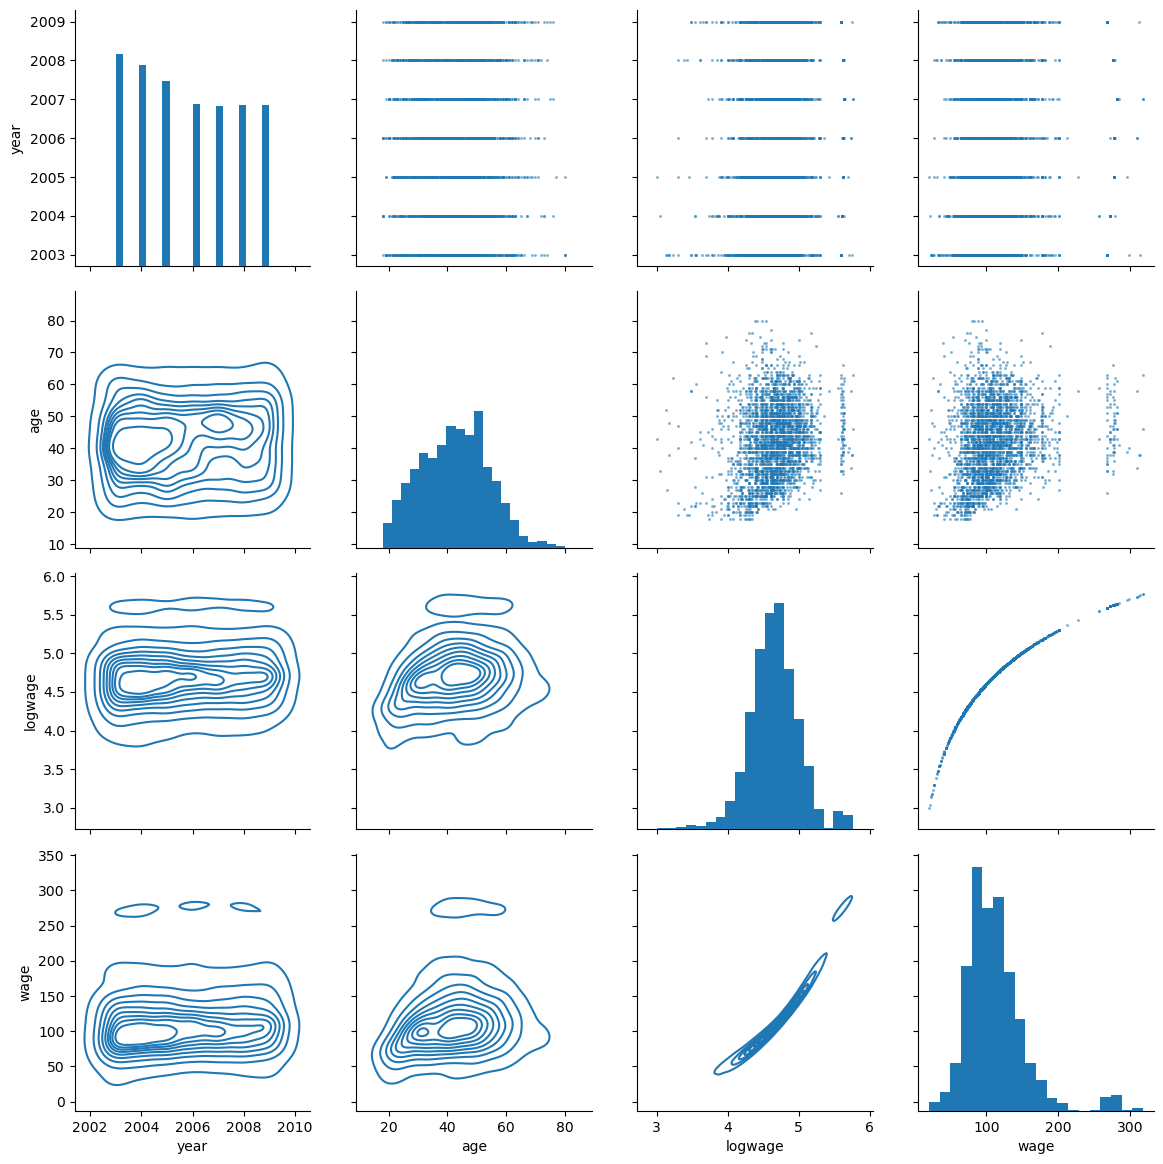

In [11]:
graph = sns.PairGrid(wage)
graph.map_upper(plt.scatter, s=3, linewidths=0.2, alpha=0.6)
graph.map_diag(plt.hist, bins=20)
graph.map_lower(sns.kdeplot)
graph.figure.set_size_inches(12, 12)

# In this excercise goal is to analyze categorical columns with some of the non-linear fitting models. I am gonna choose GAM as well as spline techniques.

In [153]:
X = wage[["age", "maritl", "jobclass"]].copy()
Y = wage["wage"]

le1 = LabelEncoder()
le2 = LabelEncoder()
X["maritl"] = le1.fit_transform(X["maritl"].astype(str))
X["jobclass"] = le2.fit_transform(X["jobclass"].astype(str)) 

X = X.astype(float)
X.head()
print(le1.classes_)
print(le2.classes_)

['1. Never Married' '2. Married' '3. Widowed' '4. Divorced' '5. Separated']
['1. Industrial' '2. Information']


In [154]:
def boxplot(df, x_ref, pred, le=None):
    df_plot = pd.DataFrame({
        x_ref: X[x_ref],
        'pred': pred
    })
    
    plt.figure(figsize=(6,4))
    df_plot.boxplot(column="pred", by=x_ref)
    plt.ylabel('Predicted target')
    plt.title(f'GAM predictions by {x_ref} status')


    if le is not None:
        plt.xticks(rotation=45, ticks=range(1,len(le.classes_)+1), labels=le.classes_)
    plt.suptitle('')
    plt.show()

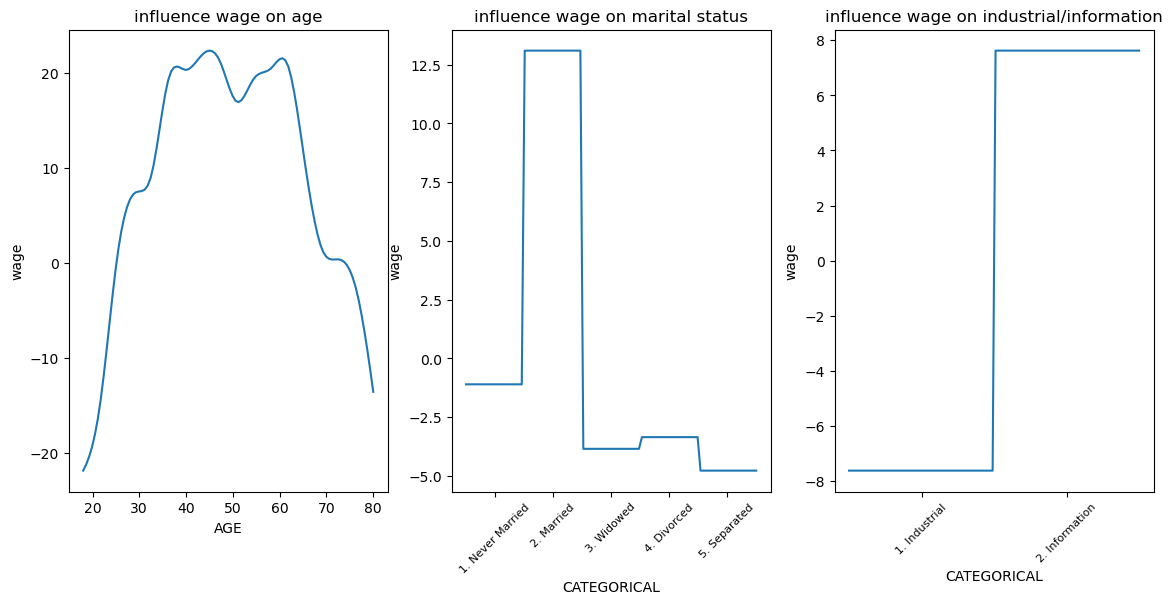

In [155]:
gam = LinearGAM(
    s(0) +
    f(1) +
    f(2)
)

gam.fit(X, Y)

y_pred = gam.predict(X.values)
legend_arr = list(["age", "marital status", "industrial/information"])

fig, axes = plt.subplots(1,3, figsize=(14,6))

for i, term in enumerate(gam.terms):
    if term.isintercept:
        continue
    XX = gam.generate_X_grid(term=i)
    ax = axes[i]
    ax.plot(XX[:, term.feature], gam.partial_dependence(term=i, X=XX))
    ax.set_title(f"influence wage on {legend_arr[i]}")
    if i!=0:
        ax.set_xlabel("CATEGORICAL")
        if i ==1:
            ax.set_xticks(range(len(le1.classes_)))
            ax.set_xticklabels(le1.classes_, rotation=45, size=8)
        else: 
            ax.set_xticks(range(len(le2.classes_)))
            ax.set_xticklabels(le2.classes_, rotation=45, size=8)
    else:
        ax.set_xlabel("AGE")
    ax.set_ylabel("wage")
plt.show()



<Figure size 600x400 with 0 Axes>

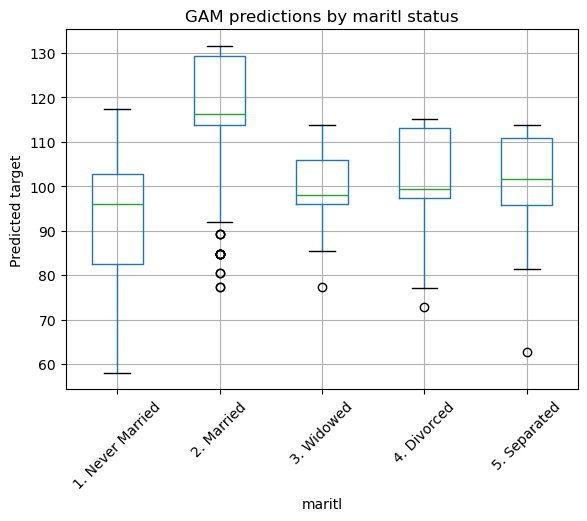

In [156]:
boxplot(X, "maritl", y_pred, le1)

<Figure size 600x400 with 0 Axes>

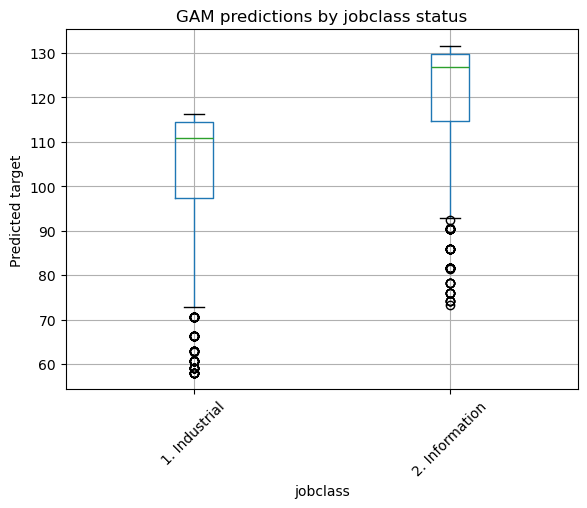

In [157]:
boxplot(X, "jobclass", y_pred, le2)

## Results: 
### 1) it seems that Information jobclass has significantly higher influence on wage than industrial one.
### 2) In maritial column Married status has the highest avg based on GAM model, so it is estimated to have the highest influence on average, but has some outliers as well. It is quite interesting information which certainly scopes outside of our topic :D